In [1]:
!git clone https://github.com/Muralidare/deepslide-demo
%cd deepslide-demo

Cloning into 'deepslide-demo'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 42 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 8.77 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/deepslide-demo


In [2]:
!pip install numpy pandas pillow scikit-image scikit-learn scipy imageio opencv-python
!pip install torch torchvision
!apt-get install openslide-tools
!pip install openslide-python

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libopenslide0
Suggested packages:
  libtiff-tools
The following NEW packages will be installed:
  libopenslide0 openslide-tools
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 104 kB of archives.
After this operation, 297 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libopenslide0 amd64 3.4.1+dfsg-5build1 [89.8 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 openslide-tools amd64 3.4.1+dfsg-5build1 [13.8 kB]
Fetched 104 kB in 1s (109 kB/s)
Selecting previously unselected package libopenslide0.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../libopenslide0_3.4.1+dfsg-5build1_amd64.deb ...
Unpacking libopenslide0 (3.4.1+dfsg-5build1) ...
Selecting previously unselected package openslide-tools.


In [3]:
!python code/1_split.py --val_wsi_per_class 0 --test_wsi_per_class 0

###############     CONFIGURATION     ###############
all_wsi:	all_wsi
val_wsi_per_class:	0
test_wsi_per_class:	0
keep_orig_copy:	True
num_workers:	8
patch_size:	224
wsi_train:	wsi_train
wsi_val:	wsi_val
wsi_test:	wsi_test
labels_train:	labels_train.csv
labels_val:	labels_val.csv
labels_test:	labels_test.csv
train_folder:	train_folder
patches_eval_train:	patches_eval_train
patches_eval_val:	patches_eval_val
patches_eval_test:	patches_eval_test
num_train_per_class:	80000
type_histopath:	True
purple_threshold:	100
purple_scale_size:	15
slide_overlap:	3
gen_val_patches_overlap_factor:	1.5
image_ext:	jpg
by_folder:	True
color_jitter_brightness:	0.5
color_jitter_contrast:	0.5
color_jitter_saturation:	0.5
color_jitter_hue:	0.2
num_epochs:	20
num_layers:	18
learning_rate:	0.001
batch_size:	16
weight_decay:	0.0001
learning_rate_decay:	0.85
resume_checkpoint:	False
save_interval:	1
checkpoints_folder:	checkpoints
checkpoint_file:	xyz.pt
pretrain:	False
log_folder:	logs
auto_select:	True
preds_t

In [4]:
!python code/2_process_patches.py --num_train_per_class 100 --type_histopath False

###############     CONFIGURATION     ###############
all_wsi:	all_wsi
val_wsi_per_class:	20
test_wsi_per_class:	30
keep_orig_copy:	True
num_workers:	8
patch_size:	224
wsi_train:	wsi_train
wsi_val:	wsi_val
wsi_test:	wsi_test
labels_train:	labels_train.csv
labels_val:	labels_val.csv
labels_test:	labels_test.csv
train_folder:	train_folder
patches_eval_train:	patches_eval_train
patches_eval_val:	patches_eval_val
patches_eval_test:	patches_eval_test
num_train_per_class:	100
type_histopath:	True
purple_threshold:	100
purple_scale_size:	15
slide_overlap:	3
gen_val_patches_overlap_factor:	1.5
image_ext:	jpg
by_folder:	True
color_jitter_brightness:	0.5
color_jitter_contrast:	0.5
color_jitter_saturation:	0.5
color_jitter_hue:	0.2
num_epochs:	20
num_layers:	18
learning_rate:	0.001
batch_size:	16
weight_decay:	0.0001
learning_rate_decay:	0.85
resume_checkpoint:	False
save_interval:	1
checkpoints_folder:	checkpoints
checkpoint_file:	xyz.pt
pretrain:	False
log_folder:	logs
auto_select:	True
preds_t

In [5]:
!cp train_folder/train/cancer/*.jpg train_folder/val/cancer/
!cp train_folder/train/normal/*.jpg train_folder/val/normal/

In [13]:
!python code/3_train.py --num_epochs 2 --batch_size 4

###############     CONFIGURATION     ###############
all_wsi:	all_wsi
val_wsi_per_class:	20
test_wsi_per_class:	30
keep_orig_copy:	True
num_workers:	8
patch_size:	224
wsi_train:	wsi_train
wsi_val:	wsi_val
wsi_test:	wsi_test
labels_train:	labels_train.csv
labels_val:	labels_val.csv
labels_test:	labels_test.csv
train_folder:	train_folder
patches_eval_train:	patches_eval_train
patches_eval_val:	patches_eval_val
patches_eval_test:	patches_eval_test
num_train_per_class:	80000
type_histopath:	True
purple_threshold:	100
purple_scale_size:	15
slide_overlap:	3
gen_val_patches_overlap_factor:	1.5
image_ext:	jpg
by_folder:	True
color_jitter_brightness:	0.5
color_jitter_contrast:	0.5
color_jitter_saturation:	0.5
color_jitter_hue:	0.2
num_epochs:	2
num_layers:	18
learning_rate:	0.001
batch_size:	4
weight_decay:	0.0001
learning_rate_decay:	0.85
resume_checkpoint:	False
save_interval:	1
checkpoints_folder:	checkpoints
checkpoint_file:	xyz.pt
pretrain:	False
log_folder:	logs
auto_select:	True
preds_t

In [7]:
!python code/4_test.py

###############     CONFIGURATION     ###############
all_wsi:	all_wsi
val_wsi_per_class:	20
test_wsi_per_class:	30
keep_orig_copy:	True
num_workers:	8
patch_size:	224
wsi_train:	wsi_train
wsi_val:	wsi_val
wsi_test:	wsi_test
labels_train:	labels_train.csv
labels_val:	labels_val.csv
labels_test:	labels_test.csv
train_folder:	train_folder
patches_eval_train:	patches_eval_train
patches_eval_val:	patches_eval_val
patches_eval_test:	patches_eval_test
num_train_per_class:	80000
type_histopath:	True
purple_threshold:	100
purple_scale_size:	15
slide_overlap:	3
gen_val_patches_overlap_factor:	1.5
image_ext:	jpg
by_folder:	True
color_jitter_brightness:	0.5
color_jitter_contrast:	0.5
color_jitter_saturation:	0.5
color_jitter_hue:	0.2
num_epochs:	20
num_layers:	18
learning_rate:	0.001
batch_size:	16
weight_decay:	0.0001
learning_rate_decay:	0.85
resume_checkpoint:	False
save_interval:	1
checkpoints_folder:	checkpoints
checkpoint_file:	xyz.pt
pretrain:	False
log_folder:	logs
auto_select:	True
preds

In [8]:
!python code/6_visualize.py

###############     CONFIGURATION     ###############
all_wsi:	all_wsi
val_wsi_per_class:	20
test_wsi_per_class:	30
keep_orig_copy:	True
num_workers:	8
patch_size:	224
wsi_train:	wsi_train
wsi_val:	wsi_val
wsi_test:	wsi_test
labels_train:	labels_train.csv
labels_val:	labels_val.csv
labels_test:	labels_test.csv
train_folder:	train_folder
patches_eval_train:	patches_eval_train
patches_eval_val:	patches_eval_val
patches_eval_test:	patches_eval_test
num_train_per_class:	80000
type_histopath:	True
purple_threshold:	100
purple_scale_size:	15
slide_overlap:	3
gen_val_patches_overlap_factor:	1.5
image_ext:	jpg
by_folder:	True
color_jitter_brightness:	0.5
color_jitter_contrast:	0.5
color_jitter_saturation:	0.5
color_jitter_hue:	0.2
num_epochs:	20
num_layers:	18
learning_rate:	0.001
batch_size:	16
weight_decay:	0.0001
learning_rate_decay:	0.85
resume_checkpoint:	False
save_interval:	1
checkpoints_folder:	checkpoints
checkpoint_file:	xyz.pt
pretrain:	False
log_folder:	logs
auto_select:	True
preds

In [9]:
!ls train_folder/train/cancer | head

cancer1_0_0.jpg
cancer1_0_139.jpg
cancer1_0_278.jpg
cancer1_0_417.jpg
cancer1_139_0.jpg
cancer1_139_139.jpg
cancer1_139_278.jpg
cancer1_139_417.jpg
cancer2_0_0.jpg
cancer2_0_139.jpg


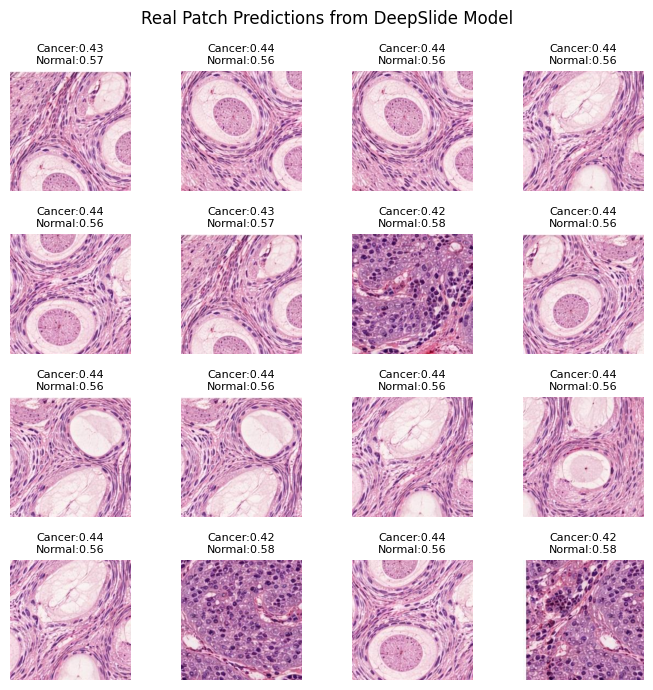

In [17]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import os, random
import matplotlib.pyplot as plt
from PIL import Image

# load model
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 2)

checkpoint = torch.load("checkpoints/resnet18_e1_va0.50000.pt", map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

# preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

classes = ["cancer","normal"]

folder = "train_folder/train/cancer"
files = random.sample(os.listdir(folder), min(16,len(os.listdir(folder))))

fig, axes = plt.subplots(4,4, figsize=(7,7))

for ax,f in zip(axes.flatten(),files):

    img = Image.open(os.path.join(folder,f)).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)[0]

    ax.imshow(img)
    ax.set_title(f"Cancer:{prob[0]:.2f}\nNormal:{prob[1]:.2f}", fontsize=8)
    ax.axis("off")

plt.suptitle("Real Patch Predictions from DeepSlide Model")
plt.tight_layout()
plt.show()

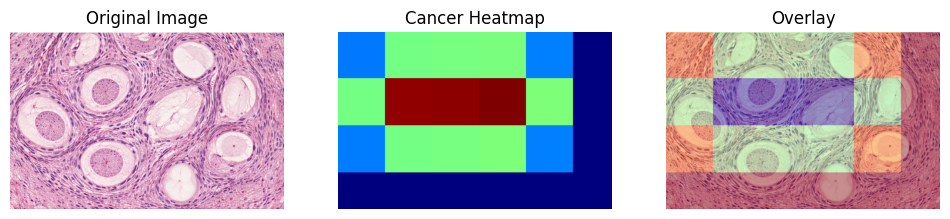

In [18]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# load trained model
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 2)

checkpoint = torch.load("checkpoints/resnet18_e1_va0.50000.pt", map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# load one image
img_path = "all_wsi/cancer/cancer1.jpg"   # change if needed
img = Image.open(img_path).convert("RGB")
img_np = np.array(img)

patch_size = 224
stride = 112   # overlap

h, w, _ = img_np.shape

heatmap = np.zeros((h, w))

for y in range(0, h-patch_size, stride):
    for x in range(0, w-patch_size, stride):

        patch = img.crop((x, y, x+patch_size, y+patch_size))
        input_tensor = transform(patch).unsqueeze(0)

        with torch.no_grad():
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)[0][0].item()  # cancer probability

        heatmap[y:y+patch_size, x:x+patch_size] += prob

# normalize
heatmap = heatmap / np.max(heatmap)

# convert heatmap to color
heatmap_color = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

# overlay heatmap
overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

# plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Cancer Heatmap")
plt.imshow(heatmap, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()